## Experiment 3: Triton Block Size Sweep 

Benchmark a Triton elementwise square kernel with `BLOCK_SIZE ∈ {128, 256, 512, 1024, 2048}` across a fixed tensor size, and compare latency, effective bandwidth, occupancy, register usage, memory throughput, grid size, stall reasons, and profiler warnings using CUDA events and Nsight Compute. The goal is to determine how Triton block size affects GPU utilization and kernel performance.


In [1]:
!nvidia-smi

Sat Sep  5 00:46:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             30W /   70W |   13199MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!pip install matplotlib

In [6]:
# import libraries
import torch # for tensor operations
import triton # for triton operations
import triton.language as tl # for triton language
import matplotlib.pyplot as plt # for plotting

# versions of libraries
print(f"torch.__version__: {torch.__version__}")
print(f"triton.__version__: {triton.__version__}")

# check if gpu is available
print(f"GPU available: {torch.cuda.is_available()}")



torch.__version__: 2.11.0+cu128
triton.__version__: 3.6.0
GPU available: True


In [7]:
# BLOCK_SIZE ∈ {128, 256, 512, 1024, 2048}
BLOCK_SIZES = [128, 256, 512, 1024, 2048]

# were going to use a large tensor size to ensure that the block size is the limiting factor
N = 2**26

In [23]:
# writing a triton square kernel
@triton.jit
def triton_square(x_ptr, y_ptr, n, BLOCK_SIZE: tl.constexpr):
    # program id
    pid = tl.program_id(0)

    offset = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    mask = offset < n
    x = tl.load(x_ptr + offset, mask=mask)
    y = x * x
    tl.store(y_ptr + offset, y, mask=mask)



In [24]:
# load the input
x = torch.randn(N, device='cuda')
# allocate the output
y = torch.empty_like(x)

print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")
    

x shape: torch.Size([67108864])
y shape: torch.Size([67108864])


In [30]:
def benchmark(N, block_size):
    # get the grid size, using bracketing to ensure the grid is a tuple
    grid= (triton.cdiv(N, block_size),)

    # warmup
    for _ in range(10):
        triton_square[grid](x, y, N, BLOCK_SIZE=block_size)

    torch.cuda.synchronize()

    # time the kernel
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    # record the start and end times
    start.record()
    triton_square[grid](x, y, N, BLOCK_SIZE=block_size)
    end.record()

    # wait for the events to complete
    torch.cuda.synchronize()

    # calculate the latency
    latency = start.elapsed_time(end)
    # calculate the effective bandwidth
    effective_bandwidth = N * 8 * 1e3/ latency  # in MB/s
    return latency, effective_bandwidth

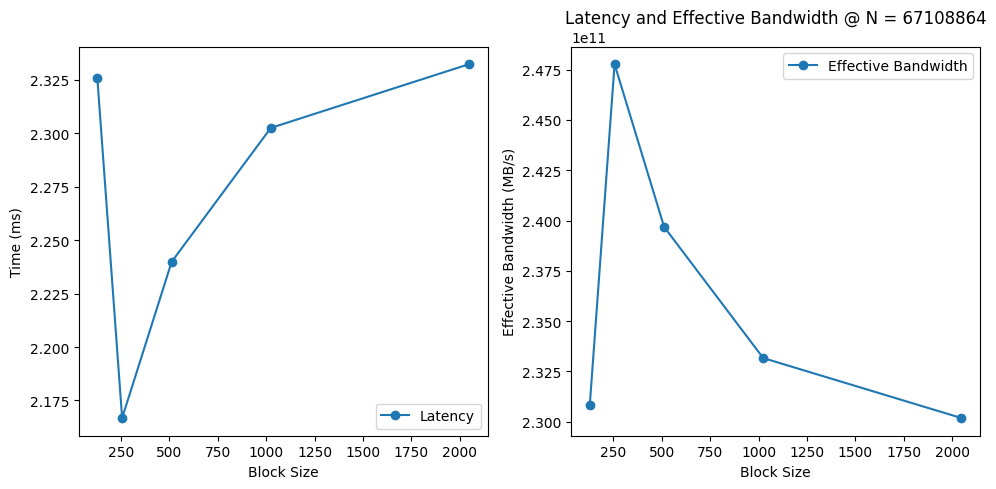

In [31]:
latencies = []
effective_bandwidths = []
for block_size in BLOCK_SIZES:
    latency, effective_bandwidth = benchmark(N, block_size)
    latencies.append(latency)
    effective_bandwidths.append(effective_bandwidth)

# plot the results
fig,axes= plt.subplots(1,2, figsize=(10, 5))
axes[0].plot(BLOCK_SIZES, latencies, label='Latency', marker='o')
axes[0].legend()
axes[0].set_xlabel('Block Size')
axes[0].set_ylabel('Time (ms)')
axes[1].plot(BLOCK_SIZES, effective_bandwidths, label='Effective Bandwidth', marker='o')
axes[1].legend()
axes[1].set_xlabel('Block Size')
axes[1].set_ylabel('Effective Bandwidth (MB/s)')
plt.title(f'Latency and Effective Bandwidth @ N = {N}')
plt.tight_layout()

plt.show()
